In [31]:
#We had to do this install because otherwise some imports below would not work
%pip install matplotlib seaborn scikit-learn scipy pandas numpy liac-arff

Note: you may need to restart the kernel to use updated packages.


In [32]:

# libraries imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.model_selection import cross_validate, KFold, train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Seed config so we get same results
np.random.seed(42)

In [33]:
#we load the file nasa93.arff

data = arff.loadarff('nasa93.arff')
df = pd.DataFrame(data[0])

print("Original dataset format:", df.shape)
print("\nFirst five rows:")
print(df.head())
print("\nf¡Dataset info:")
print(df.info())
print("\n target variable - act_effort - characteristics:")
print(df['act_effort'].describe())

Original dataset format: (93, 24)

First five rows:
   recordnumber projectname                   cat2  forg center    year  \
0           1.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
1           2.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
2           3.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
3           4.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   
4           5.0       b'de'  b'avionicsmonitoring'  b'g'   b'2'  1979.0   

              mode  rely  data  cplx  ...  acap  aexp  pcap  vexp  lexp  modp  \
0  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
1  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
2  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
3  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   
4  b'semidetached'  b'h'  b'l'  b'h'  ...  b'n'  b'n'  b'n'  b'n'  b'h'  b'h'   

   tool  s

Null data per collumn:
recordnumber     0
projectname      0
cat2             0
forg             0
center           0
year             0
mode             0
rely             0
data             0
cplx             0
time             0
stor             0
virt             0
turn             0
acap             0
aexp             0
pcap             0
vexp             0
lexp             0
modp             0
tool             0
sced             0
equivphyskloc    0
act_effort       0
dtype: int64


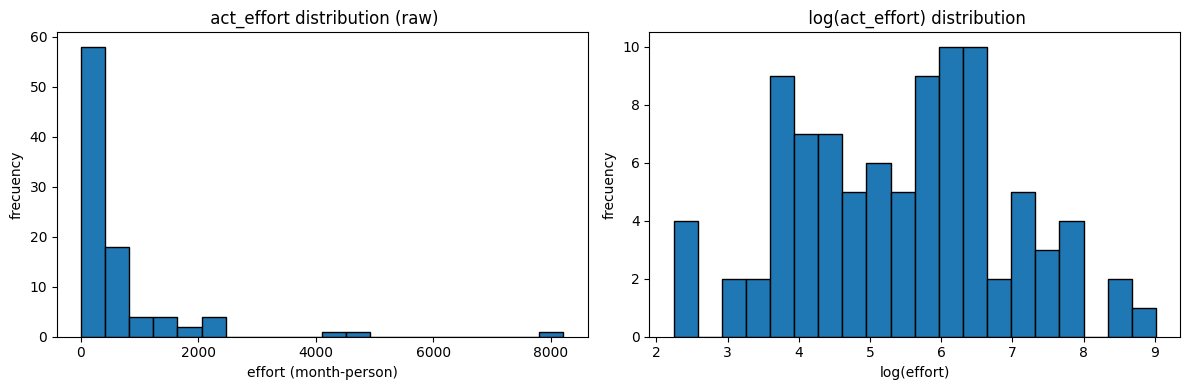

<Figure size 640x480 with 0 Axes>

Distribution plot saved to 'visual_analysis.png'


In [ ]:
#Basic analysis of data


print("Null data per collumn:")
print(df.isnull().sum())

# effort distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['act_effort'], bins=20, edgecolor='black')
plt.title(' act_effort distribution (raw)')
plt.xlabel('effort (month-person)')
plt.ylabel('frecuency')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['act_effort']), bins=20, edgecolor='black')
plt.title(' log(act_effort) distribution')
plt.xlabel('log(effort)')
plt.ylabel('frecuency')

plt.tight_layout()
plt.savefig('visual_alanysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Distribution plot saved to 'visual_analysis.png'")

In [35]:

# indentify and classify variables


# variables to remove
vars_drop = ['recordnumber', 'projectname']

# Categorical variables
cat_vars = ['cat2', 'forg', 'center', 'mode', 'rely', 'data', 'cplx', 
            'time', 'stor', 'virt', 'turn', 'acap', 'aexp', 'pcap', 
            'vexp', 'lexp', 'modp', 'tool', 'sced']

# numeric variables
num_vars = ['year', 'equivphyskloc']

# target variable
target = 'act_effort'

print("Categorical variables to be coded:", len(cat_vars))
print("Numerical variables to be coded", len(num_vars))

Categorical variables to be coded: 19
Numerical variables to be coded 2


In [36]:

# # Preprocessing and cleaning outliers


# 1. removing outliers
Q1 = df['act_effort'].quantile(0.25)   
Q3 = df['act_effort'].quantile(0.75)
IQR = Q3 - Q1
mask_clean = (df[target] >= (Q1 - 1.5 * IQR)) & (df[target] <= (Q3 + 1.5 * IQR))

df_clean = df[mask_clean].copy()
print(f"Dataset cleaned: {len(df_clean)}/{len(df)} removed proyects ({100*(1-len(df_clean)/len(df)):.1f}% outliers)")

for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].str.decode('utf-8')

# 2 Variables
vars_drop = ['recordnumber', 'projectname']
cat_vars = ['cat2', 'forg', 'center', 'mode', 'rely', 'data', 'cplx', 
            'time', 'stor', 'virt', 'turn', 'acap', 'aexp', 'pcap', 
            'vexp', 'lexp', 'modp', 'tool', 'sced']
num_vars = ['year', 'equivphyskloc']
target = 'act_effort'
 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_vars),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_vars)
    ])

# 4. create clean datasets
X_clean = df_clean.drop(columns=[target] + vars_drop)
y_raw_clean = df_clean[target]
y_log_clean = np.log1p(y_raw_clean)

print(f"Forma X limpio: {X_clean.shape}")
print(f"Forma y limpia: {y_raw_clean.shape}")
print(f"cleaned effort statistics :\n{y_raw_clean.describe()}")

X_processed = preprocessor.fit_transform(X_clean)

# save in .npy format
np.save('X_processed.npy', X_processed)
np.save('y_raw_clean.npy', y_raw_clean.values)
np.save('y_log_clean.npy', y_log_clean.values)




Dataset cleaned: 83/93 removed proyects (10.8% outliers)
Forma X limpio: (83, 21)
Forma y limpia: (83,)
cleaned effort statistics :
count      83.000000
mean      318.050602
std       336.453809
min         8.400000
25%        60.000000
50%       192.000000
75%       444.000000
max      1368.000000
Name: act_effort, dtype: float64


In [37]:

# Linear regresion model
lr_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('selector', SelectKBest(f_regression, k=20)),  
    ('regressor', LinearRegression())
])

lasso_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('selector', SelectKBest(f_regression, k=20)),  
    ('regressor', Lasso(alpha=0.01)) 
])

In [38]:

# Cross validation with k = 10

def calcular_metricas(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mdae = median_absolute_error(y_true, y_pred)

    naive_pred = np.full_like(y_true, np.mean(y_true), dtype=float)

    mae_naive = mean_absolute_error(y_true, naive_pred)
    mdae_naive = median_absolute_error(y_true, naive_pred)

    mase = mae / mae_naive if mae_naive != 0 else np.nan
    mdase = mdae / mdae_naive if mdae_naive != 0 else np.nan

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MdAE': mdae,
        'MASE': mase,
        'MdASE': mdase
    }

cv = KFold(n_splits=10, shuffle=True, random_state=42)
metricas_lr = []
metricas_lasso = []

print("10-FOLD CROSS VALIDATION\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_clean), start=1):
    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train_log, y_test_log = y_log_clean.iloc[train_idx], y_log_clean.iloc[test_idx]
    y_test_raw = np.expm1(y_test_log)

    # training and prediction for linear regression
    lr_pipeline.fit(X_train, y_train_log)
    y_pred_lr = np.expm1(lr_pipeline.predict(X_test))
    m_lr = calcular_metricas(y_test_raw, y_pred_lr)
    metricas_lr.append(m_lr)

    # training and prediction LASSO
    lasso_pipeline.fit(X_train, y_train_log)
    y_pred_lasso = np.expm1(lasso_pipeline.predict(X_test))
    m_lasso = calcular_metricas(y_test_raw, y_pred_lasso)
    metricas_lasso.append(m_lasso)

    print(f"Fold {fold:2d} | LR MAE: {m_lr['MAE']:8.2f} | LASSO MAE: {m_lasso['MAE']:8.2f}")

# final results
res_lr = pd.DataFrame(metricas_lr).mean().round(2)
res_lasso = pd.DataFrame(metricas_lasso).mean().round(2)

comparativa = pd.DataFrame({
    'Metric': res_lr.index,
    'Linear Regression': res_lr.values,
    'LASSO': res_lasso.values
})

print("\n----- Final results -----")
print(comparativa)
comparativa.to_csv('models-comparison.csv', index=False)



10-FOLD CROSS VALIDATION

Fold  1 | LR MAE:    64.99 | LASSO MAE:    50.27
Fold  2 | LR MAE:   272.73 | LASSO MAE:   258.38
Fold  3 | LR MAE:   540.85 | LASSO MAE:   512.12
Fold  4 | LR MAE:   540.45 | LASSO MAE:   466.56
Fold  5 | LR MAE:   574.01 | LASSO MAE:   167.08
Fold  6 | LR MAE:   108.81 | LASSO MAE:    94.02
Fold  7 | LR MAE:   133.42 | LASSO MAE:   198.54
Fold  8 | LR MAE:   162.15 | LASSO MAE:   197.17
Fold  9 | LR MAE:   164.31 | LASSO MAE:   201.78
Fold 10 | LR MAE:   236.76 | LASSO MAE:   323.47

----- Final results -----
  Metric  Linear Regression   LASSO
0    MAE             279.85  246.94
1   RMSE             518.61  410.66
2   MdAE             127.02  123.89
3   MASE               1.55    1.16
4  MdASE               0.71    0.73


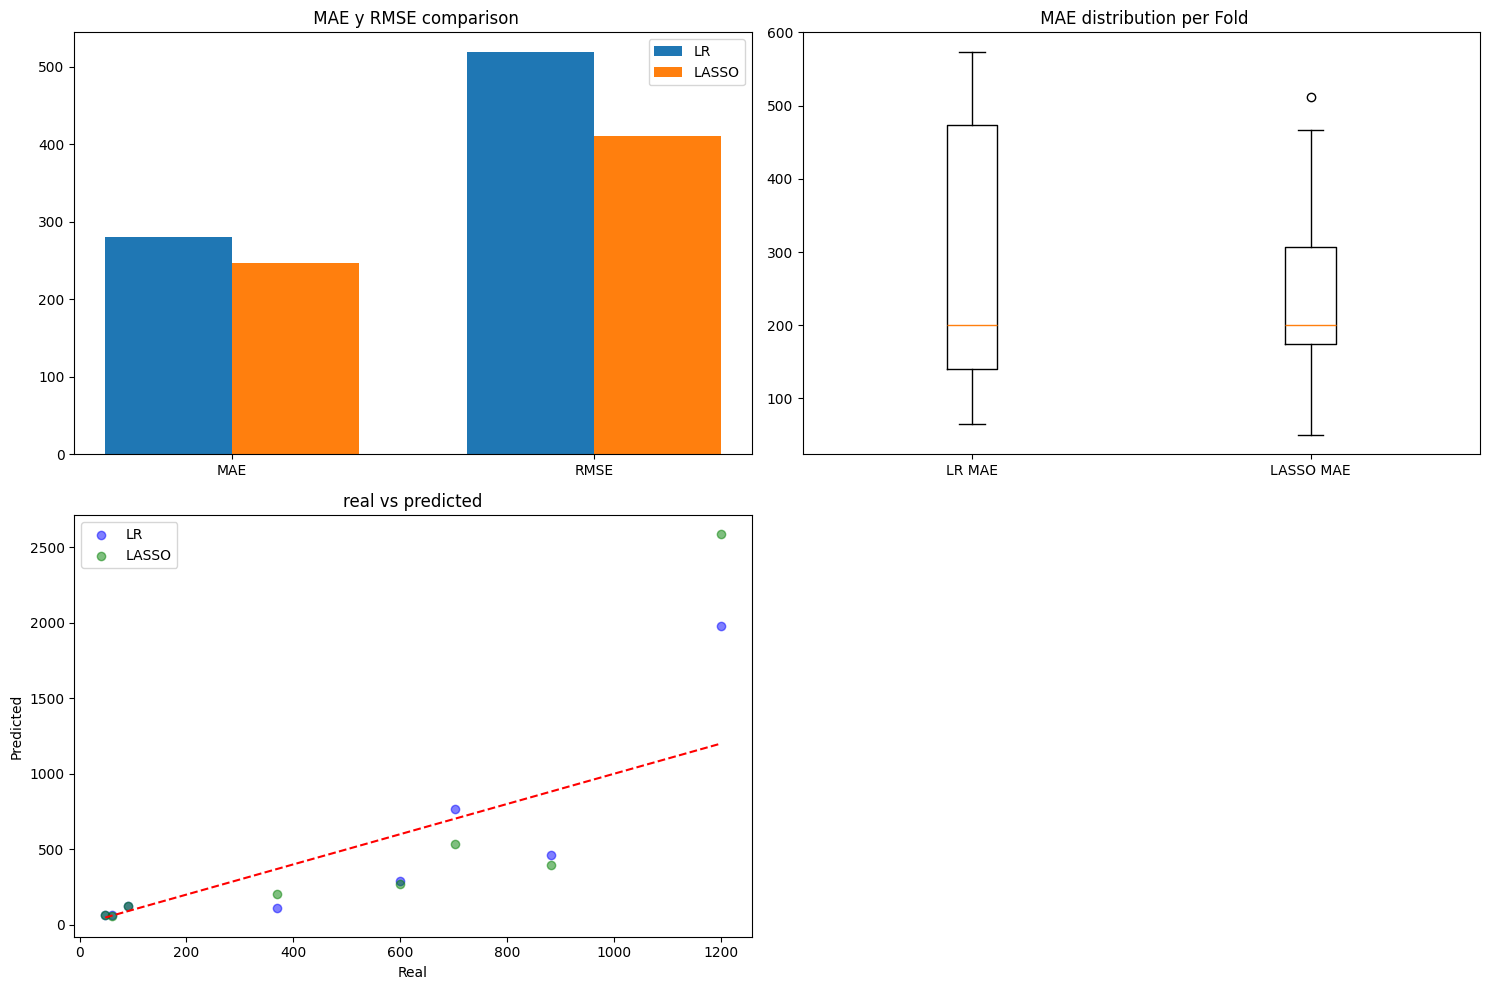

In [39]:
plt.figure(figsize=(15, 10))

#  MAE and RMSE comparison
plt.subplot(2, 2, 1)
x = np.arange(len(comparativa['Metric'][:2]))
width = 0.35
plt.bar(x - width/2, comparativa['Linear Regression'][:2], width, label='LR')
plt.bar(x + width/2, comparativa['LASSO'][:2], width, label='LASSO')
plt.xticks(x, comparativa['Metric'][:2])
plt.title(' MAE y RMSE comparison')
plt.legend()

# errors per fold for each model
plt.subplot(2, 2, 2)
data_to_plot = [pd.DataFrame(metricas_lr)['MAE'], pd.DataFrame(metricas_lasso)['MAE']]
plt.boxplot(data_to_plot, labels=['LR MAE', 'LASSO MAE'])
plt.title(' MAE distribution per Fold')

# real vs predicted (last fold)
plt.subplot(2, 2, 3)
plt.scatter(y_test_raw, y_pred_lr, alpha=0.5, label='LR', color='blue')
plt.scatter(y_test_raw, y_pred_lasso, alpha=0.5, label='LASSO', color='green')
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicted')
plt.title('real vs predicted')
plt.legend()

plt.tight_layout()
plt.savefig('graphs.png')
plt.show()

DIscussion and analysis

The 10-fold cross-validation results demonstrate that the LASSO model outperforms Linear Regression across nearly all key metrics, reducing the average error to a MAE of 246.94, compared to 279.85 for the linear model.

This enhancement is particularly evident in the RMSE (410.66 for LASSO vs. 518.61 for LR), indicating that LASSO's regularization effectively minimizes the impact of significant outliers and provides greater consistency, as shown by the narrower error distribution across folds in the boxplots. Ultimately, with a MASE of 1.16, LASSO proves to be a more robust solution with superior generalization capabilities for this dataset.